# Miner Comparison: Inductive vs Split Miner

Compare process models discovered by the inductive miner and split miner on the same event log, measuring fitness and precision for both.

In [1]:
import pm4py
import pandas as pd
from pm4py.algo.discovery.split_miner import algorithm as split_miner
from pm4py.convert import convert_to_petri_net

In [ ]:
LOG_PATH = "../../data/villach/processflow_export.xes"
event_log = pm4py.read_xes(LOG_PATH)
print(f"Traces: {len(event_log)}")

c:\Users\safaya\Documents\GitHub\process-fragment-miner\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

Traces: 815


## Inductive Miner

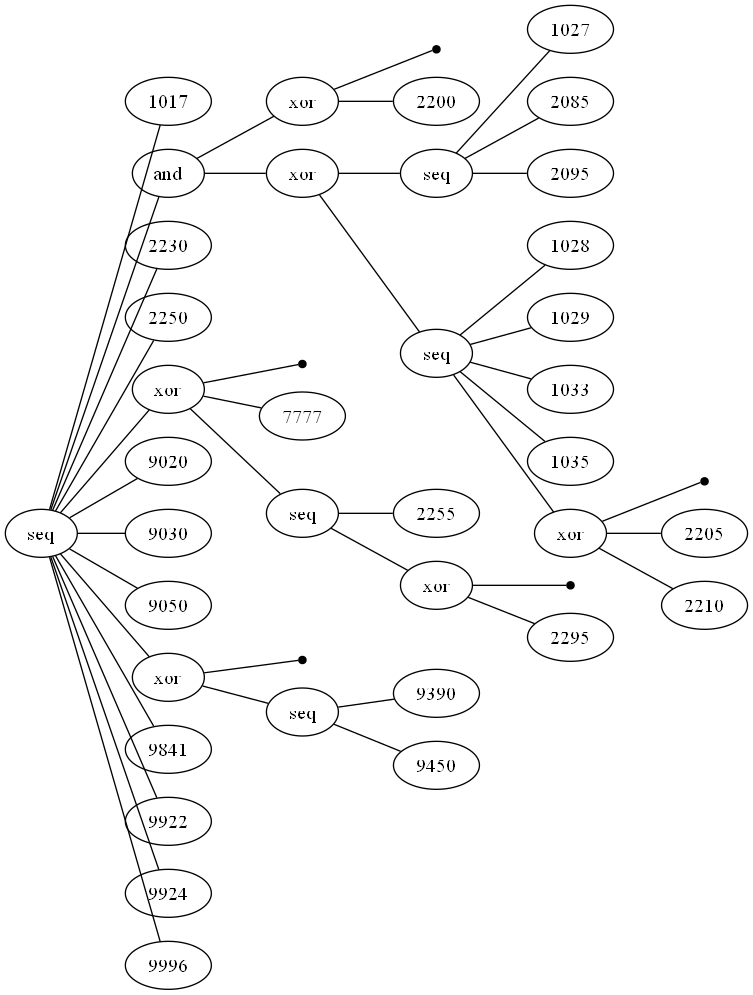

In [8]:
tree = pm4py.discover_process_tree_inductive(event_log)
pm4py.view_process_tree(tree)

In [4]:
net_im_fm = convert_to_petri_net(tree)
inductive_fitness = pm4py.fitness_alignments(event_log, *net_im_fm)['log_fitness']
inductive_precision = pm4py.precision_alignments(event_log, *net_im_fm)
print(f"Inductive Miner — fitness={inductive_fitness:.4f}, precision={inductive_precision:.4f}")

aligning log, completed variants ::   0%|          | 0/11 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/88 [00:00<?, ?it/s]

Inductive Miner — fitness=1.0000, precision=0.7087


## Split Miner

Split miner BPMN: 38 nodes


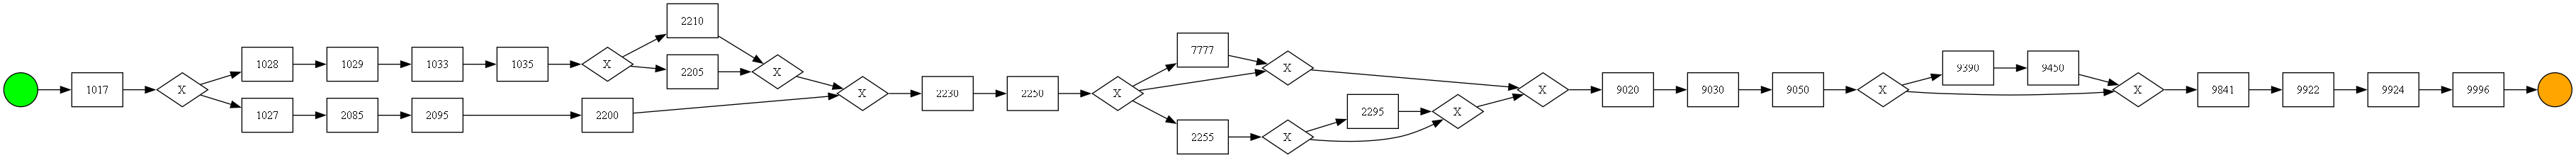

In [5]:
bpmn = split_miner.apply(event_log)
print(f"Split miner BPMN: {len(bpmn.get_nodes())} nodes")
pm4py.view_bpmn(bpmn)

In [6]:
net_im_fm = convert_to_petri_net(bpmn)
split_fitness = pm4py.fitness_alignments(event_log, *net_im_fm)['log_fitness']
split_precision = pm4py.precision_alignments(event_log, *net_im_fm)
print(f"Split Miner — fitness={split_fitness:.4f}, precision={split_precision:.4f}")

aligning log, completed variants ::   0%|          | 0/11 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/88 [00:00<?, ?it/s]

Split Miner — fitness=0.9807, precision=0.9108


## Comparison

In [7]:
pd.DataFrame({
    "Miner": ["Inductive", "Split"],
    "Fitness": [f"{inductive_fitness:.4f}", f"{split_fitness:.4f}"],
    "Precision": [f"{inductive_precision:.4f}", f"{split_precision:.4f}"],
})

,Miner,Fitness,Precision
0,Inductive,1.0000,0.7087
1,Split,0.9807,0.9108
